# # Lynceus Fraud Detection System

# ## Model Interpretability using SHAP

This notebook explains the predictions made by the trained fraud detection model.

### Objectives

- Load production artifacts
- Explain global feature importance
- Explain individual predictions
- Visualize feature impact
- Improve model transparency

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import json
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import shap

shap.initjs()

In [2]:
DATA_DIR = Path("/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/data/synthetic")

ARTIFACT_DIR = Path("/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/artifacts")

TEST_PATH = DATA_DIR / "transactions_test.csv"

PIPELINE_PATH = ARTIFACT_DIR / "preprocessing_pipeline.joblib"

MODEL_PATH = ARTIFACT_DIR / "best_model.joblib"

METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

In [3]:
preprocessor = joblib.load(PIPELINE_PATH)

model = joblib.load(MODEL_PATH)

with open(METADATA_PATH) as f:
    metadata = json.load(f)

print(type(model))
print(metadata)

<class 'lightgbm.sklearn.LGBMClassifier'>
{'model_name': 'LGBMClassifier', 'model_version': '1.0.0', 'optimal_threshold': 0.4000000000000001, 'feature_count': 41, 'validation_metrics': {'accuracy': 0.9845333333333334, 'precision': 0.7058823529411765, 'recall': 0.5341246290801187, 'f1_score': 0.6081081081081081, 'roc_auc': 0.8837575592981062, 'pr_auc': 0.5836839758163083}, 'test_metrics': {'accuracy': 0.9834, 'precision': 0.7414634146341463, 'recall': 0.4367816091954023, 'f1_score': 0.5497287522603979, 'roc_auc': 0.8663020387158318, 'pr_auc': 0.5640666643027727}}


In [4]:
# load raw test data

test_df = pd.read_csv(
    TEST_PATH,
    parse_dates=["timestamp"]
)

TARGET = "fraud_label"

X = test_df.drop(columns=TARGET)

y = test_df[TARGET]

In [5]:
# prepare raw features

binary_features = [

    "is_weekend",

    "is_new_receiver",

    "device_trusted",

    "cross_border",

    "high_risk_country"

]

X = X.drop(columns="timestamp")

X[binary_features] = X[binary_features].astype("int8")

In [7]:
# apply processing

X_processed = preprocessor.transform(X)

feature_names = preprocessor.get_feature_names_out()

X_processed = pd.DataFrame(

    X_processed,

    columns=feature_names

)

In [8]:
# create shap explainer

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

if isinstance(
    model,
    (
        RandomForestClassifier,
        XGBClassifier,
        LGBMClassifier,
        CatBoostClassifier
    )
):
    explainer = shap.TreeExplainer(model)

elif isinstance(model, LogisticRegression):
    explainer = shap.LinearExplainer(
        model,
        X_processed
    )

else:
    explainer = shap.Explainer(
        model,
        X_processed
    )

In [9]:
# compute shap values

sample_size = min(1000, len(X_processed))

X_sample = X_processed.iloc[:sample_size]

shap_values = explainer(X_sample)

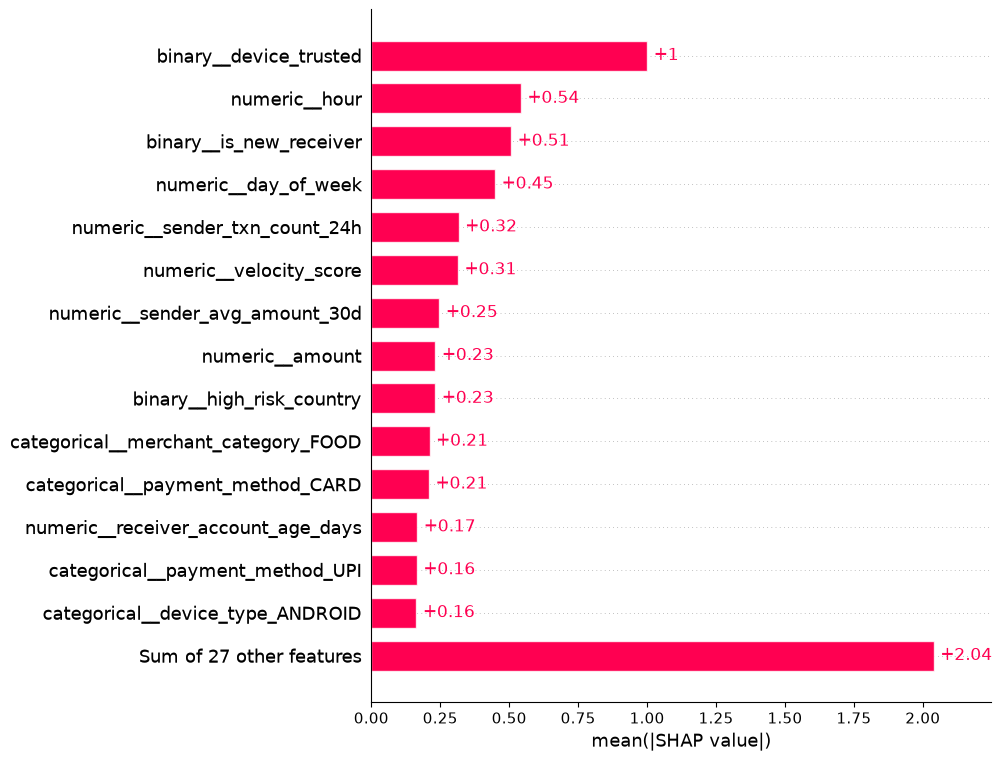

In [10]:
# global feature importance

shap.plots.bar(
    shap_values,
    max_display=15
)

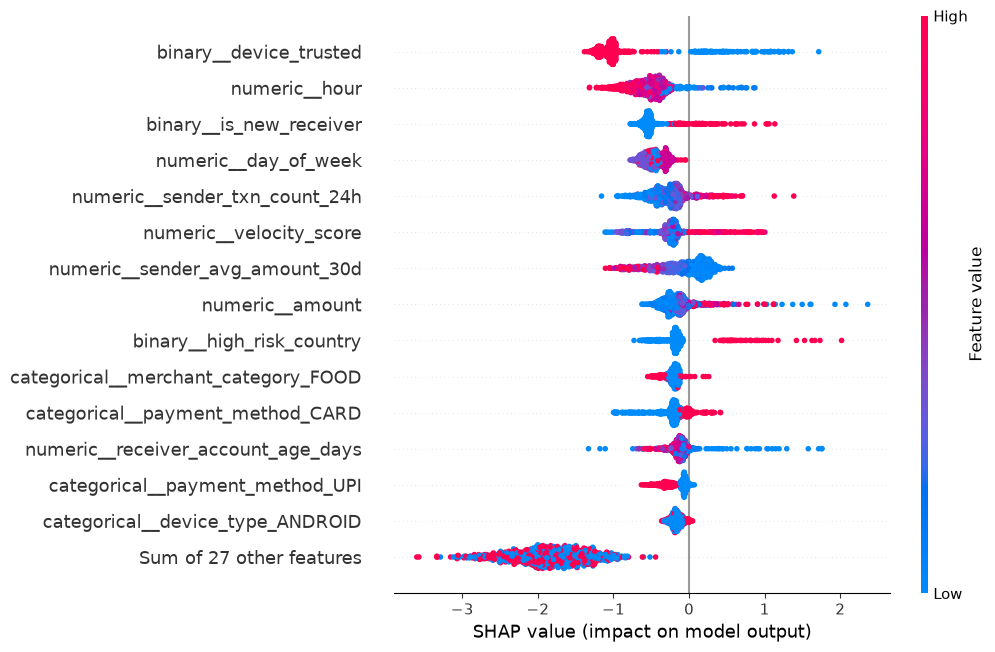

In [11]:
# beeswarm plot

shap.plots.beeswarm(
    shap_values,
    max_display=15
)

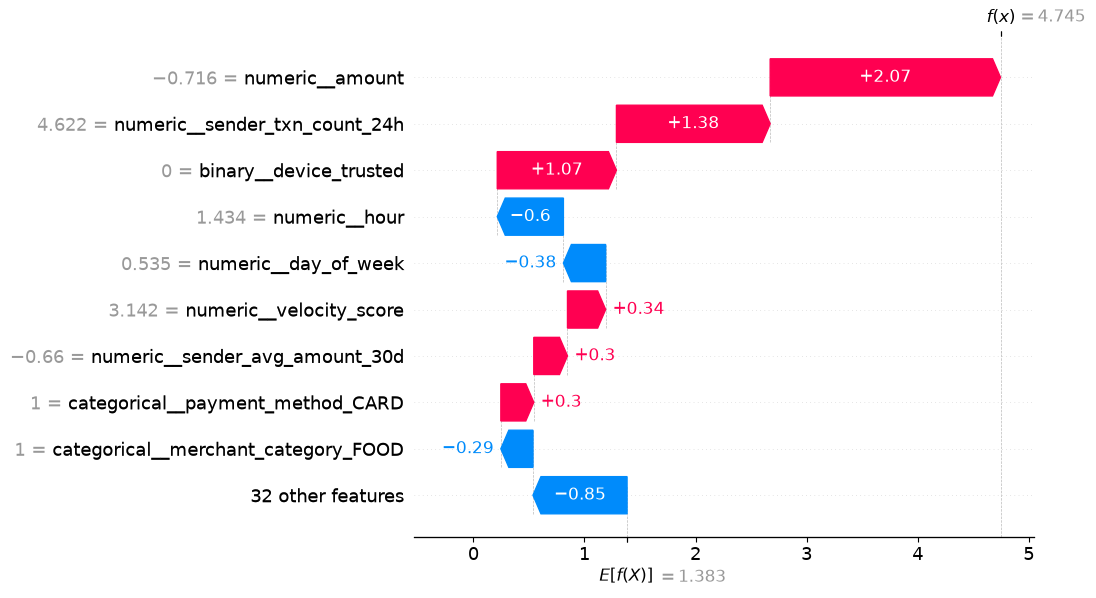

In [12]:
# waterfall plot

fraud_index = np.argmax(
    model.predict_proba(X_sample)[:,1]
)

shap.plots.waterfall(
    shap_values[fraud_index]
)

In [13]:
# force plot

shap.plots.force(
    shap_values[fraud_index]
)

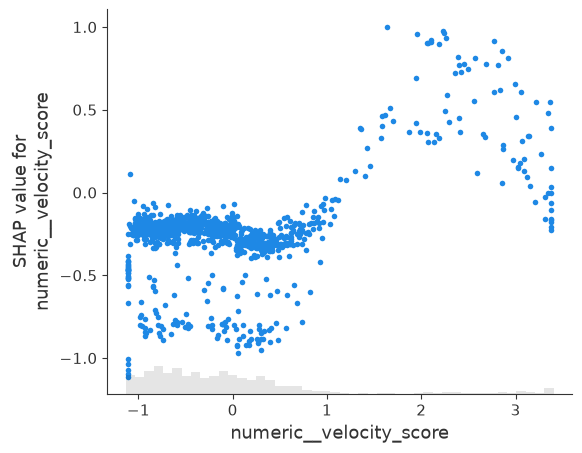

In [14]:
# dependence plot

feature = "numeric__velocity_score"

if feature in X_sample.columns:

    shap.plots.scatter(
        shap_values[:, feature]
    )

else:

    print(f"{feature} not found.")

In [15]:
# top features table

importance = np.abs(
    shap_values.values
).mean(axis=0)

importance_df = pd.DataFrame({

    "Feature": X_sample.columns,

    "Mean |SHAP|": importance

})

importance_df = importance_df.sort_values(

    by="Mean |SHAP|",

    ascending=False

)

importance_df.head(20)

,Feature,Mean |SHAP|
12,binary__device_trusted,1.000206
1,numeric__hour,0.542105
11,binary__is_new_receiver,0.506890
2,numeric__day_of_week,0.448552
5,numeric__sender_txn_count_24h,0.316234
9,numeric__velocity_score,0.313942
7,numeric__sender_avg_amount_30d,0.246338
0,numeric__amount,0.231852
14,binary__high_risk_country,0.231645
26,categorical__merchant_category_FOOD,0.210939


In [16]:
# save feature importance

importance_path = ARTIFACT_DIR / "feature_importance.csv"

importance_df.to_csv(

    importance_path,

    index=False

)

print(f"Saved to:\n{importance_path}")

Saved to:
/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/artifacts/feature_importance.csv


In [17]:
# notebook summary

print("=" * 70)

print("Model Interpretability Completed")

print("=" * 70)

print(f"Model              : {metadata['model_name']}")

print(f"Samples Explained  : {len(X_sample)}")

print(f"Features           : {X_sample.shape[1]}")

print()

print("Artifacts")

print(f"• {importance_path.name}")

print()

print("Generated Visualizations")

print("• Global Feature Importance")

print("• Beeswarm Plot")

print("• Waterfall Plot")

print("• Force Plot")

print("• Dependence Plot")

print("=" * 70)

Model Interpretability Completed
Model              : LGBMClassifier
Samples Explained  : 1000
Features           : 41

Artifacts
• feature_importance.csv

Generated Visualizations
• Global Feature Importance
• Beeswarm Plot
• Waterfall Plot
• Force Plot
• Dependence Plot


In [18]:
print(feature_names)

['numeric__amount' 'numeric__hour' 'numeric__day_of_week'
 'numeric__sender_account_age_days' 'numeric__receiver_account_age_days'
 'numeric__sender_txn_count_24h' 'numeric__receiver_txn_count_24h'
 'numeric__sender_avg_amount_30d' 'numeric__receiver_avg_amount_30d'
 'numeric__velocity_score' 'binary__is_weekend' 'binary__is_new_receiver'
 'binary__device_trusted' 'binary__cross_border'
 'binary__high_risk_country' 'categorical__currency_EUR'
 'categorical__currency_GBP' 'categorical__currency_INR'
 'categorical__currency_USD' 'categorical__payment_method_BANK_TRANSFER'
 'categorical__payment_method_CARD' 'categorical__payment_method_UPI'
 'categorical__payment_method_WALLET'
 'categorical__merchant_category_EDUCATION'
 'categorical__merchant_category_ELECTRONICS'
 'categorical__merchant_category_ENTERTAINMENT'
 'categorical__merchant_category_FOOD'
 'categorical__merchant_category_FUEL'
 'categorical__merchant_category_HEALTHCARE'
 'categorical__merchant_category_OTHER'
 'categorical_